In [1]:
#!/usr/bin/env python3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# -----------------------------
# Load data
# -----------------------------
print("Loading data...")
df_strong_weak = pd.read_csv(
    "/scratch1/smaruj/generate_cell_type_specific_features/fold0_0.5_H1hESC_strong_HFF_weak_stats.tsv",
    sep="\t"
)
df_weak_strong = pd.read_csv(
    "/scratch1/smaruj/generate_cell_type_specific_features/fold0_0.5_H1hESC_weak_HFF_strong_stats.tsv",
    sep="\t"
)

print(f"H1hESC_strong -> HFF_weak: {len(df_strong_weak)} samples")
print(f"H1hESC_weak -> HFF_strong: {len(df_weak_strong)} samples")

Loading data...
H1hESC_strong -> HFF_weak: 64 samples
H1hESC_weak -> HFF_strong: 64 samples


In [3]:
def get_model_averages(df, cell_type, model_type='optimization'):
    """
    Get average URQ values across optimization (0,1) or validation (2,3) models.
    Returns dict with 'init' and 'result' averages.
    """
    if model_type == 'optimization':
        model_indices = [0, 1]
    else:  # validation
        model_indices = [2, 3]
    
    init_values = []
    result_values = []
    
    for model_idx in model_indices:
        init_col = f"URQ_init_{cell_type}_model{model_idx}"
        result_col = f"URQ_result_{cell_type}_model{model_idx}"
        
        if init_col in df.columns and result_col in df.columns:
            init_values.append(df[init_col])
            result_values.append(df[result_col])
    
    return {
        'init': np.mean(init_values, axis=0),
        'result': np.mean(result_values, axis=0)
    }

In [4]:
# -----------------------------
# Direction 1: H1hESC_strong -> HFF_weak
# -----------------------------

print("\nProcessing Direction 1: H1hESC_strong -> HFF_weak...")

# Get optimization models
h1_opt_dir1 = get_model_averages(df_strong_weak, 'H1hESC', 'optimization')
hff_opt_dir1 = get_model_averages(df_strong_weak, 'HFF', 'optimization')

# Get validation models
h1_val_dir1 = get_model_averages(df_strong_weak, 'H1hESC', 'validation')
hff_val_dir1 = get_model_averages(df_strong_weak, 'HFF', 'validation')


Processing Direction 1: H1hESC_strong -> HFF_weak...


/tmp/SLURM_2467168/ipykernel_2933050/2158121133.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, showmeans=True,


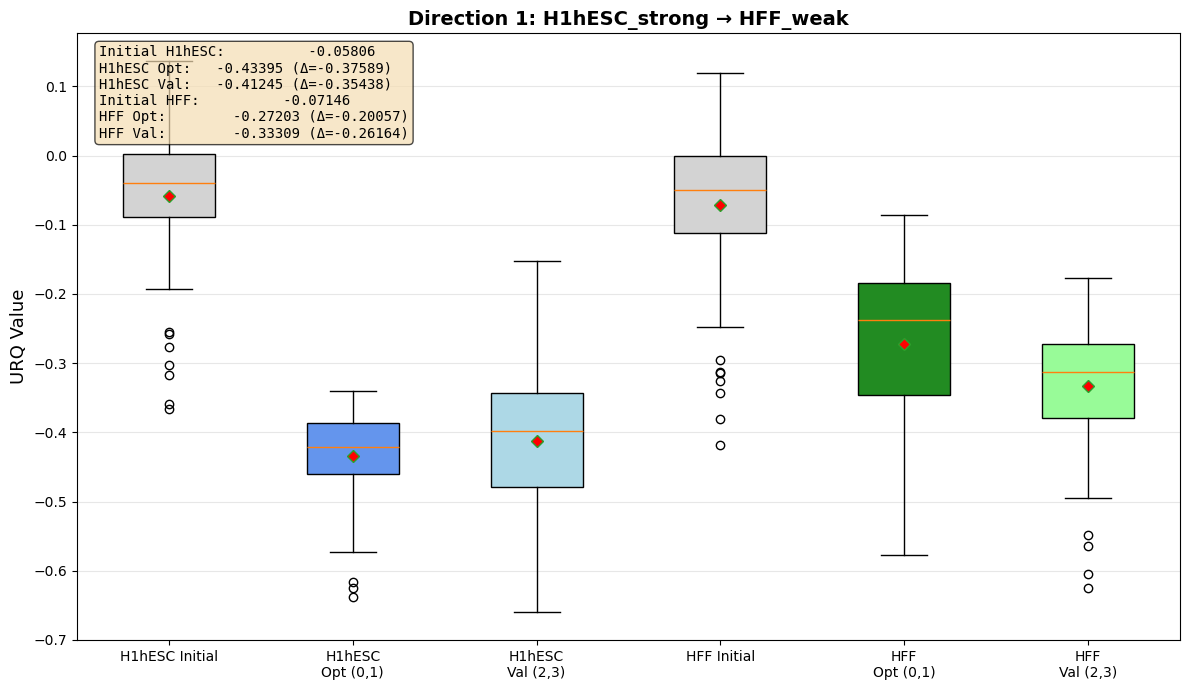

In [5]:
# Create plot for Direction 1
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

data_to_plot = [
    h1_opt_dir1['init'],
    h1_opt_dir1['result'],
    h1_val_dir1['result'],
    hff_opt_dir1['init'],
    hff_opt_dir1['result'],
    hff_val_dir1['result']
]

labels = [
    'H1hESC Initial',
    'H1hESC\nOpt (0,1)',
    'H1hESC\nVal (2,3)',
    'HFF Initial',
    'HFF\nOpt (0,1)',
    'HFF\nVal (2,3)'
]

bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='red', markersize=6))

# Color the boxes
colors = ['lightgray', 'cornflowerblue', 'lightblue', 'lightgray', 'forestgreen', 'palegreen']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('URQ Value', fontsize=13)
ax.set_title('Direction 1: H1hESC_strong → HFF_weak', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add statistics
init_h1_mean = np.mean(h1_opt_dir1['init'])
h1_opt_mean = np.mean(h1_opt_dir1['result'])
h1_val_mean = np.mean(h1_val_dir1['result'])
init_hff_mean = np.mean(hff_opt_dir1['init'])
hff_opt_mean = np.mean(hff_opt_dir1['result'])
hff_val_mean = np.mean(hff_val_dir1['result'])

stats_text = (
    f"Initial H1hESC:          {init_h1_mean:.5f}\n"
    f"H1hESC Opt:   {h1_opt_mean:.5f} (Δ={h1_opt_mean - init_h1_mean:+.5f})\n"
    f"H1hESC Val:   {h1_val_mean:.5f} (Δ={h1_val_mean - init_h1_mean:+.5f})\n"
    f"Initial HFF:          {init_hff_mean:.5f}\n"
    f"HFF Opt:        {hff_opt_mean:.5f} (Δ={hff_opt_mean - init_hff_mean:+.5f})\n"
    f"HFF Val:        {hff_val_mean:.5f} (Δ={hff_val_mean - init_hff_mean:+.5f})"
)
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
        verticalalignment='top', fontsize=10, family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
# plt.savefig('/scratch1/smaruj/generate_cell_type_specific_features/direction1_urq_comparison.png', 
#             dpi=300, bbox_inches='tight')
# print("Saved: direction1_urq_comparison.png")
plt.show()

In [6]:
# -----------------------------
# Direction 2: H1hESC_weak -> HFF_strong
# -----------------------------

print("\nProcessing Direction 2: H1hESC_weak -> HFF_strong...")

# Get optimization models
h1_opt_dir2 = get_model_averages(df_weak_strong, 'H1hESC', 'optimization')
hff_opt_dir2 = get_model_averages(df_weak_strong, 'HFF', 'optimization')

# Get validation models
h1_val_dir2 = get_model_averages(df_weak_strong, 'H1hESC', 'validation')
hff_val_dir2 = get_model_averages(df_weak_strong, 'HFF', 'validation')


Processing Direction 2: H1hESC_weak -> HFF_strong...


/tmp/SLURM_2467168/ipykernel_2933050/3322858088.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, showmeans=True,


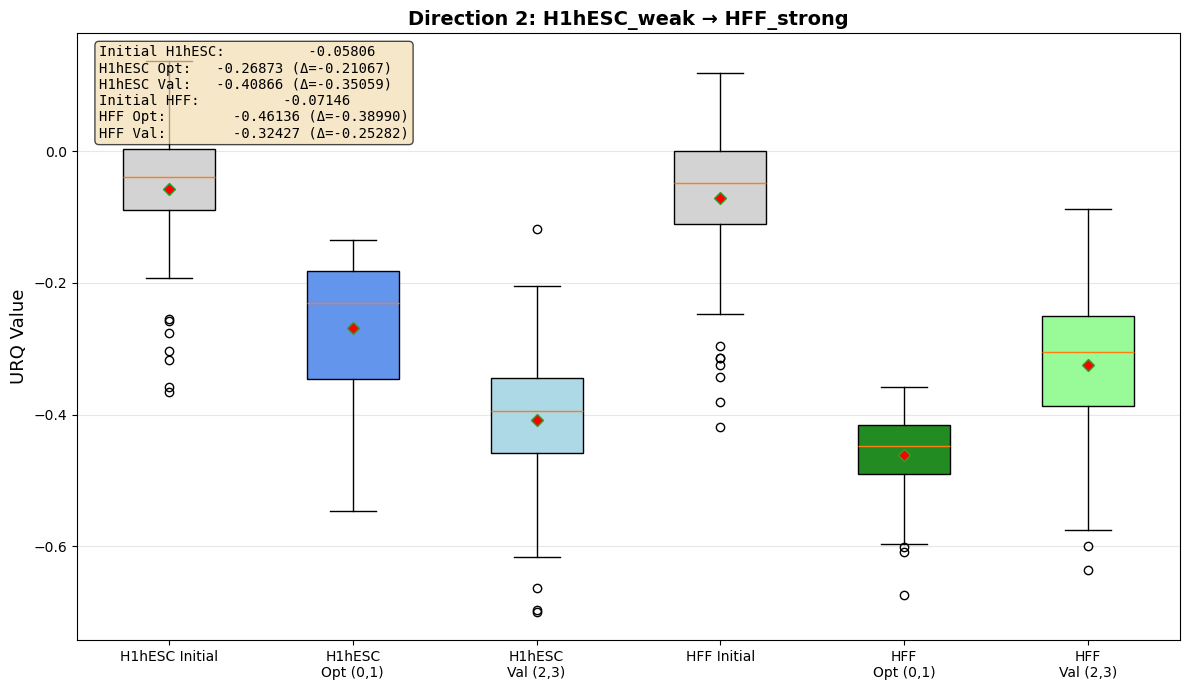

In [7]:
# Create plot for Direction 2
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

data_to_plot = [
    h1_opt_dir2['init'],
    h1_opt_dir2['result'],
    h1_val_dir2['result'],
    hff_opt_dir2['init'],
    hff_opt_dir2['result'],
    hff_val_dir2['result']
]

labels = [
    'H1hESC Initial',
    'H1hESC\nOpt (0,1)',
    'H1hESC\nVal (2,3)',
    'HFF Initial',
    'HFF\nOpt (0,1)',
    'HFF\nVal (2,3)'
]

bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='red', markersize=6))

# Color the boxes
colors = ['lightgray', 'cornflowerblue', 'lightblue', 'lightgray', 'forestgreen', 'palegreen']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('URQ Value', fontsize=13)
ax.set_title('Direction 2: H1hESC_weak → HFF_strong', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add statistics
init_h1_mean = np.mean(h1_opt_dir2['init'])
h1_opt_mean = np.mean(h1_opt_dir2['result'])
h1_val_mean = np.mean(h1_val_dir2['result'])
init_hff_mean = np.mean(hff_opt_dir2['init'])
hff_opt_mean = np.mean(hff_opt_dir2['result'])
hff_val_mean = np.mean(hff_val_dir2['result'])

stats_text = (
    f"Initial H1hESC:          {init_h1_mean:.5f}\n"
    f"H1hESC Opt:   {h1_opt_mean:.5f} (Δ={h1_opt_mean - init_h1_mean:+.5f})\n"
    f"H1hESC Val:   {h1_val_mean:.5f} (Δ={h1_val_mean - init_h1_mean:+.5f})\n"
    f"Initial HFF:          {init_hff_mean:.5f}\n"
    f"HFF Opt:        {hff_opt_mean:.5f} (Δ={hff_opt_mean - init_hff_mean:+.5f})\n"
    f"HFF Val:        {hff_val_mean:.5f} (Δ={hff_val_mean - init_hff_mean:+.5f})"
)
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
        verticalalignment='top', fontsize=10, family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
# plt.savefig('/scratch1/smaruj/generate_cell_type_specific_features/direction2_urq_comparison.png', 
#             dpi=300, bbox_inches='tight')
# print("Saved: direction2_urq_comparison.png")
plt.show()

In [8]:
# -----------------------------
# Print summary statistics
# -----------------------------

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print("\n--- Direction 1: H1hESC_strong → HFF_weak ---")
print(f"Initial:              {np.mean(h1_opt_dir1['init']):.6f} ± {np.std(h1_opt_dir1['init']):.6f}")
print(f"H1hESC Opt (0,1):     {np.mean(h1_opt_dir1['result']):.6f} ± {np.std(h1_opt_dir1['result']):.6f}  (Δ={np.mean(h1_opt_dir1['result']) - np.mean(h1_opt_dir1['init']):+.6f})")
print(f"H1hESC Val (2,3):     {np.mean(h1_val_dir1['result']):.6f} ± {np.std(h1_val_dir1['result']):.6f}  (Δ={np.mean(h1_val_dir1['result']) - np.mean(h1_opt_dir1['init']):+.6f})")
print(f"HFF Opt (0,1):        {np.mean(hff_opt_dir1['result']):.6f} ± {np.std(hff_opt_dir1['result']):.6f}  (Δ={np.mean(hff_opt_dir1['result']) - np.mean(h1_opt_dir1['init']):+.6f})")
print(f"HFF Val (2,3):        {np.mean(hff_val_dir1['result']):.6f} ± {np.std(hff_val_dir1['result']):.6f}  (Δ={np.mean(hff_val_dir1['result']) - np.mean(h1_opt_dir1['init']):+.6f})")

print("\n--- Direction 2: H1hESC_weak → HFF_strong ---")
print(f"Initial:              {np.mean(h1_opt_dir2['init']):.6f} ± {np.std(h1_opt_dir2['init']):.6f}")
print(f"H1hESC Opt (0,1):     {np.mean(h1_opt_dir2['result']):.6f} ± {np.std(h1_opt_dir2['result']):.6f}  (Δ={np.mean(h1_opt_dir2['result']) - np.mean(h1_opt_dir2['init']):+.6f})")
print(f"H1hESC Val (2,3):     {np.mean(h1_val_dir2['result']):.6f} ± {np.std(h1_val_dir2['result']):.6f}  (Δ={np.mean(h1_val_dir2['result']) - np.mean(h1_opt_dir2['init']):+.6f})")
print(f"HFF Opt (0,1):        {np.mean(hff_opt_dir2['result']):.6f} ± {np.std(hff_opt_dir2['result']):.6f}  (Δ={np.mean(hff_opt_dir2['result']) - np.mean(h1_opt_dir2['init']):+.6f})")
print(f"HFF Val (2,3):        {np.mean(hff_val_dir2['result']):.6f} ± {np.std(hff_val_dir2['result']):.6f}  (Δ={np.mean(hff_val_dir2['result']) - np.mean(h1_opt_dir2['init']):+.6f})")

print("\nAnalysis complete!")


SUMMARY STATISTICS

--- Direction 1: H1hESC_strong → HFF_weak ---
Initial:              -0.058062 ± 0.110689
H1hESC Opt (0,1):     -0.433948 ± 0.065166  (Δ=-0.375886)
H1hESC Val (2,3):     -0.412446 ± 0.117651  (Δ=-0.354384)
HFF Opt (0,1):        -0.272027 ± 0.115502  (Δ=-0.213965)
HFF Val (2,3):        -0.333091 ± 0.102902  (Δ=-0.275029)

--- Direction 2: H1hESC_weak → HFF_strong ---
Initial:              -0.058062 ± 0.110689
H1hESC Opt (0,1):     -0.268734 ± 0.102998  (Δ=-0.210672)
H1hESC Val (2,3):     -0.408656 ± 0.120846  (Δ=-0.350594)
HFF Opt (0,1):        -0.461356 ± 0.067636  (Δ=-0.403294)
HFF Val (2,3):        -0.324273 ± 0.107908  (Δ=-0.266211)

Analysis complete!


### AlphaGenome Validation

In [10]:
# -----------------------------
# Load AlphaGenome data
# -----------------------------
print("\nLoading AlphaGenome data...")
alpha_strong_weak = pd.read_csv(
    "/scratch1/smaruj/alpha_genome_validation/cell_type_specific_boundary/H1hESC_strong_HFF_weak_alphagenome_results.tsv",
    sep="\t"
)
alpha_weak_strong = pd.read_csv(
    "/scratch1/smaruj/alpha_genome_validation/cell_type_specific_boundary/H1hESC_weak_HFF_strong_alphagenome_results.tsv",
    sep="\t"
)

print(f"AlphaGenome H1hESC_strong -> HFF_weak: {len(alpha_strong_weak)} samples")
print(f"AlphaGenome H1hESC_weak -> HFF_strong: {len(alpha_weak_strong)} samples")


Loading AlphaGenome data...
AlphaGenome H1hESC_strong -> HFF_weak: 64 samples
AlphaGenome H1hESC_weak -> HFF_strong: 64 samples


In [11]:
# AlphaGenome data
alpha_h1_init_dir1 = alpha_strong_weak['alpha_H1hESC_og_urq'].values
alpha_h1_result_dir1 = alpha_strong_weak['alpha_H1hESC_ed_urq'].values
alpha_hff_init_dir1 = alpha_strong_weak['alpha_HFF_og_urq'].values
alpha_hff_result_dir1 = alpha_strong_weak['alpha_HFF_ed_urq'].values

/tmp/SLURM_2467168/ipykernel_2933050/1916986293.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, showmeans=True,


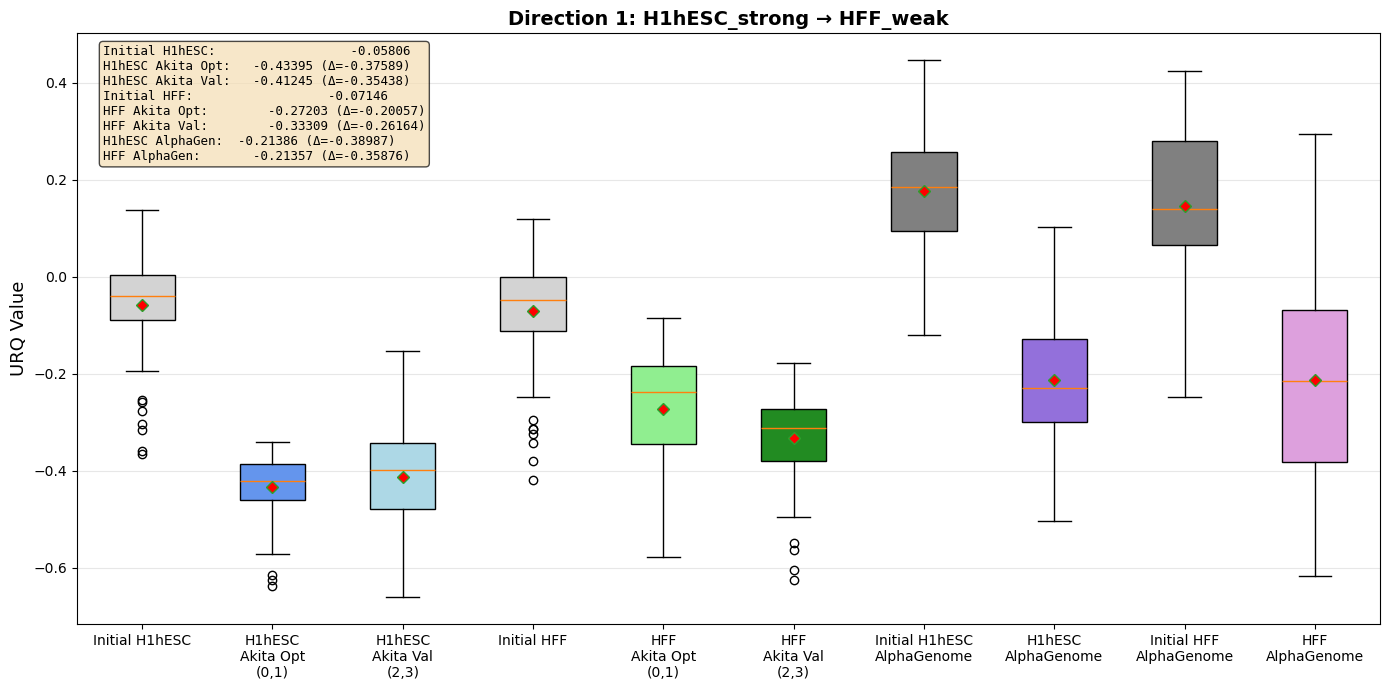

In [16]:
# Create plot for Direction 1
fig, ax = plt.subplots(1, 1, figsize=(14, 7))

data_to_plot = [
    h1_opt_dir1['init'],
    h1_opt_dir1['result'],
    h1_val_dir1['result'],
    hff_opt_dir1['init'],
    hff_opt_dir1['result'],
    hff_val_dir1['result'],
    alpha_h1_init_dir1,
    alpha_h1_result_dir1,
    alpha_hff_init_dir1,
    alpha_hff_result_dir1
]

labels = [
    'Initial H1hESC',
    'H1hESC\nAkita Opt\n(0,1)',
    'H1hESC\nAkita Val\n(2,3)',
    'Initial HFF',
    'HFF\nAkita Opt\n(0,1)',
    'HFF\nAkita Val\n(2,3)',
    'Initial H1hESC\nAlphaGenome',
    'H1hESC\nAlphaGenome',
    'Initial HFF\nAlphaGenome',
    'HFF\nAlphaGenome'
]

bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='red', markersize=6))

# Color the boxes
colors = ['lightgray', 'cornflowerblue', 'lightblue', 'lightgray', 'lightgreen', 'forestgreen', 'gray', 'mediumpurple', 'gray', 'plum']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('URQ Value', fontsize=13)
ax.set_title('Direction 1: H1hESC_strong → HFF_weak', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add statistics
init_h1_mean = np.mean(h1_opt_dir1['init'])
h1_opt_mean = np.mean(h1_opt_dir1['result'])
h1_val_mean = np.mean(h1_val_dir1['result'])
init_hff_mean = np.mean(hff_opt_dir1['init'])
hff_opt_mean = np.mean(hff_opt_dir1['result'])
hff_val_mean = np.mean(hff_val_dir1['result'])
alpha_h1_init_mean = np.mean(alpha_h1_init_dir1)
alpha_h1_mean = np.mean(alpha_h1_result_dir1)
alpha_hff_init_mean = np.mean(alpha_hff_init_dir1)
alpha_hff_mean = np.mean(alpha_hff_result_dir1)

stats_text = (
    f"Initial H1hESC:                  {init_h1_mean:.5f}\n"
    f"H1hESC Akita Opt:   {h1_opt_mean:.5f} (Δ={h1_opt_mean - init_h1_mean:+.5f})\n"
    f"H1hESC Akita Val:   {h1_val_mean:.5f} (Δ={h1_val_mean - init_h1_mean:+.5f})\n"
    f"Initial HFF:                  {init_hff_mean:.5f}\n"
    f"HFF Akita Opt:        {hff_opt_mean:.5f} (Δ={hff_opt_mean - init_hff_mean:+.5f})\n"
    f"HFF Akita Val:        {hff_val_mean:.5f} (Δ={hff_val_mean - init_hff_mean:+.5f})\n"
    f"H1hESC AlphaGen:  {alpha_h1_mean:.5f} (Δ={alpha_h1_mean - alpha_h1_init_mean:+.5f})\n"
    f"HFF AlphaGen:       {alpha_hff_mean:.5f} (Δ={alpha_hff_mean - alpha_hff_init_mean:+.5f})"
)
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
        verticalalignment='top', fontsize=9, family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
# plt.savefig('/scratch1/smaruj/generate_cell_type_specific_features/direction1_urq_with_alpha.png', 
#             dpi=300, bbox_inches='tight')
# print("Saved: direction1_urq_with_alpha.png")


In [15]:
# -----------------------------
# Direction 2: H1hESC_weak -> HFF_strong
# -----------------------------

print("\nProcessing Direction 2: H1hESC_weak -> HFF_strong...")

# AlphaGenome data
alpha_h1_init_dir2 = alpha_weak_strong['alpha_H1hESC_og_urq'].values
alpha_h1_result_dir2 = alpha_weak_strong['alpha_H1hESC_ed_urq'].values
alpha_hff_init_dir2 = alpha_weak_strong['alpha_HFF_og_urq'].values
alpha_hff_result_dir2 = alpha_weak_strong['alpha_HFF_ed_urq'].values


Processing Direction 2: H1hESC_weak -> HFF_strong...


/tmp/SLURM_2467168/ipykernel_2933050/1327916302.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, showmeans=True,


Text(0.02, 0.98, 'Initial H1hESC:                  -0.05806\nH1hESC Akita Opt:   -0.26873 (Δ=-0.21067)\nH1hESC Akita Val:   -0.40866 (Δ=-0.35059)\nInitial HFF:                  -0.07146\nHFF Akita Opt:        -0.46136 (Δ=-0.38990)\nHFF Akita Val:        -0.32427 (Δ=-0.25282)\nH1hESC AlphaGen:  -0.20648 (Δ=-0.38249)\nHFF AlphaGen:       -0.20928 (Δ=+0.00000)')

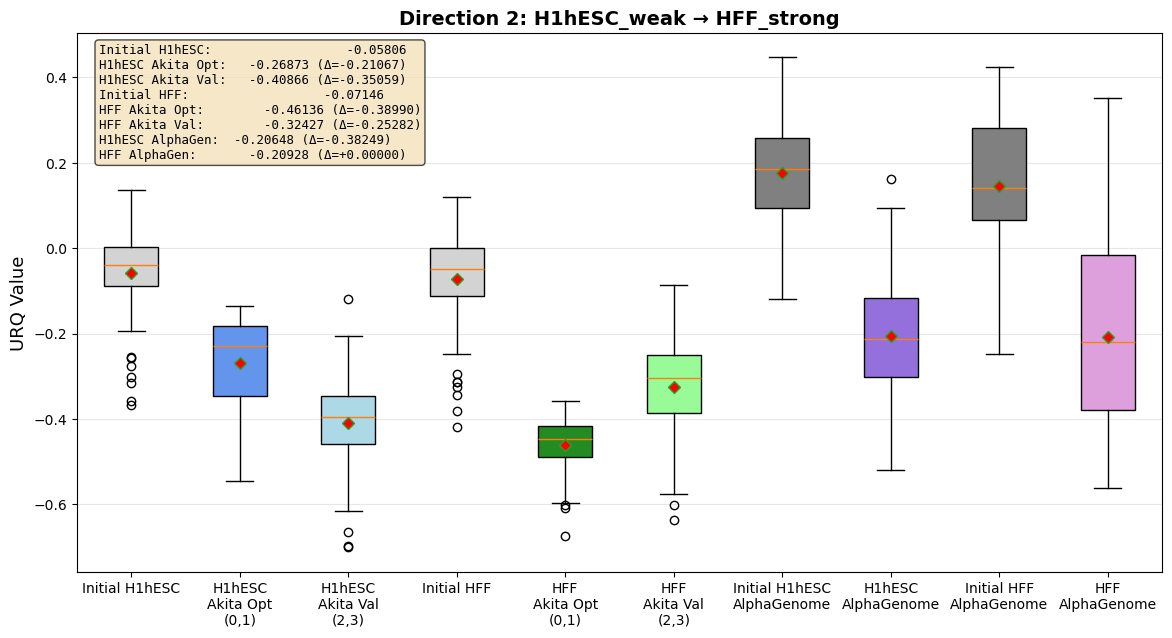

In [19]:
# Create plot for Direction 2
fig, ax = plt.subplots(1, 1, figsize=(14, 7))

data_to_plot = [
    h1_opt_dir2['init'],
    h1_opt_dir2['result'],
    h1_val_dir2['result'],
    hff_opt_dir2['init'],
    hff_opt_dir2['result'],
    hff_val_dir2['result'],
    alpha_h1_init_dir2,
    alpha_h1_result_dir2,
    alpha_hff_init_dir2,
    alpha_hff_result_dir2
]

labels = [
    'Initial H1hESC',
    'H1hESC\nAkita Opt\n(0,1)',
    'H1hESC\nAkita Val\n(2,3)',
    'Initial HFF',
    'HFF\nAkita Opt\n(0,1)',
    'HFF\nAkita Val\n(2,3)',
    'Initial H1hESC\nAlphaGenome',
    'H1hESC\nAlphaGenome',
    'Initial HFF\nAlphaGenome',
    'HFF\nAlphaGenome'
]

bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='red', markersize=6))

# Color the boxes
colors = ['lightgray', 'cornflowerblue', 'lightblue', 'lightgray', 'forestgreen', 'palegreen', 'gray', 'mediumpurple', 'gray', 'plum']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('URQ Value', fontsize=13)
ax.set_title('Direction 2: H1hESC_weak → HFF_strong', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add statistics
init_H1hESC_mean = np.mean(h1_opt_dir2['init'])
h1_opt_mean = np.mean(h1_opt_dir2['result'])
h1_val_mean = np.mean(h1_val_dir2['result'])
init_HFF_mean = np.mean(hff_opt_dir2['init'])
hff_opt_mean = np.mean(hff_opt_dir2['result'])
hff_val_mean = np.mean(hff_val_dir2['result'])
alpha_h1_mean_init = np.mean(alpha_h1_init_dir2)
alpha_h1_mean = np.mean(alpha_h1_result_dir2)
alpha_hff_mean_init = np.mean(alpha_hff_init_dir2)
alpha_hff_mean = np.mean(alpha_hff_result_dir2)

stats_text = (
    f"Initial H1hESC:                  {init_H1hESC_mean:.5f}\n"
    f"H1hESC Akita Opt:   {h1_opt_mean:.5f} (Δ={h1_opt_mean - init_H1hESC_mean:+.5f})\n"
    f"H1hESC Akita Val:   {h1_val_mean:.5f} (Δ={h1_val_mean - init_H1hESC_mean:+.5f})\n"
    f"Initial HFF:                  {init_HFF_mean:.5f}\n"
    f"HFF Akita Opt:        {hff_opt_mean:.5f} (Δ={hff_opt_mean - init_HFF_mean:+.5f})\n"
    f"HFF Akita Val:        {hff_val_mean:.5f} (Δ={hff_val_mean - init_HFF_mean:+.5f})\n"
    f"H1hESC AlphaGen:  {alpha_h1_mean:.5f} (Δ={alpha_h1_mean - alpha_h1_mean_init:+.5f})\n"
    f"HFF AlphaGen:       {alpha_hff_mean:.5f} (Δ={alpha_hff_mean - alpha_hff_mean:+.5f})"
)
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
        verticalalignment='top', fontsize=9, family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# plt.tight_layout()
# plt.savefig('/scratch1/smaruj/generate_cell_type_specific_features/direction2_urq_with_alpha.png', 
#             dpi=300, bbox_inches='tight')
# print("Saved: direction2_urq_with_alpha.png")
